# ARTI 308 – Lab 5: Feature Engineering (Classification)

## Heart Disease Prediction using the UCI Heart Disease Dataset

### Lab Focus
This dataset contains medical information about patients such as age, cholesterol level, blood pressure, chest pain type, and other clinical measurements.

The dataset is relatively clean and requires minimal preprocessing. In this lab, we focus on **feature engineering for a classification task**, rather than extensive data cleaning.

The goal is to explore how creating new medical risk-related features can improve the performance of machine learning models.

---

### Objective
Build a baseline model to predict **Heart Disease (target)** and understand how feature engineering affects model performance and feature importance.

Target variable:

- **0 = No Heart Disease**
- **1 = Presence of Heart Disease**

---

### In this lab we will:

1. Load and inspect the **Heart Disease dataset**
2. Define the **target variable and select usable predictors**
3. Engineer new medical risk-related features (ratio features, risk scores, and age groups)
4. Encode categorical features if necessary
5. Train a baseline **Random Forest classifier**
6. Evaluate model performance and interpret **feature importance**

## 1. Setup and imports

In [25]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Display plots nicely
%matplotlib inline
sns.set_style("whitegrid")

## 2. Load the dataset

In [26]:
# Dataset URL (UCI Heart Disease)
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names (dataset does not include headers)
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

# Load dataset
df = pd.read_csv(DATA_URL, names=columns, na_values="?")

# Display first rows
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


The first rows confirm that the dataset loaded correctly.

Each row represents a patient record containing medical attributes such as age, cholesterol level, blood pressure, chest pain type, and other clinical measurements used to predict the presence of heart disease (`target`).

## 3. Quick dataset checks (cleanliness confirmation)

In [27]:
# Dataset shape
print("Shape:", df.shape)

# Missing values per column
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (303, 14)

Missing values per column:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
missing_count,0,0,0,0,0,0,0,0,0,0,0,4,2,0



Duplicate rows: 0


We perform quick checks to confirm the dataset quality.

- We inspect the dataset shape.
- We check for missing values in each column.
- We check if there are any duplicate rows.

These checks help ensure the dataset is suitable for feature engineering and model training.

## 4. Target variable and class balance

In [28]:
# Define target column
target_col = "target"

# Count values of target classes
df[target_col].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

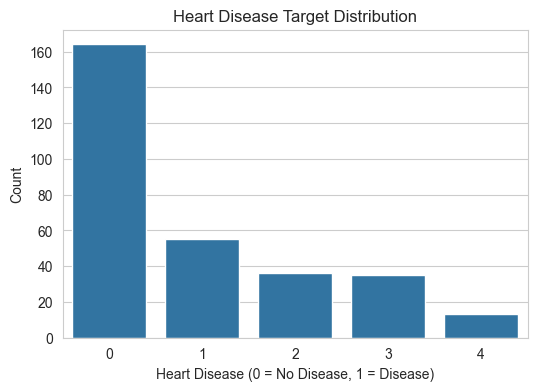

In [29]:
# Plot class distribution
plt.figure(figsize=(6,4))

sns.countplot(x=target_col, data=df)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")

plt.show()

This step examines the distribution of the target variable.

The target variable represents whether a patient has heart disease:

- 0 → No heart disease
- 1 → Heart disease present

Checking the class balance helps us understand whether the dataset is balanced or if one class dominates the dataset.

## 5. Identify feature types

In [30]:
df.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

### Feature Types

Most features in this dataset are numerical medical measurements such as age, blood pressure, cholesterol, and heart rate.

Some variables like **cp**, **thal**, and **slope** represent categorical information but are already encoded as numbers.

The **target** variable indicates heart disease:
- 0 = No heart disease  
- 1 = Heart disease present

## 6. Leakage awareness (important)

## Leakage awareness (important)

When building a prediction model, we must avoid using features that reveal the outcome directly.

In this dataset, the goal is to predict **heart disease (target)** using patient medical attributes such as age, cholesterol, blood pressure, and heart rate.

All features represent measurements taken before diagnosis, so they are appropriate predictors for the model.

## 7. Feature engineering

### 7.1 Medical risk-based features



In [8]:
df_fe = df.copy()

# Cholesterol to age ratio
df_fe["chol_age_ratio"] = df_fe["chol"] / df_fe["age"]

# Blood pressure and cholesterol combined risk score
df_fe["bp_chol_risk"] = df_fe["trestbps"] + df_fe["chol"]

# Heart rate stress indicator
df_fe["heart_stress"] = df_fe["thalach"] - df_fe["oldpeak"]

# Preview new features
df_fe[["chol_age_ratio","bp_chol_risk","heart_stress"]].head()

,chol_age_ratio,bp_chol_risk,heart_stress
0,3.698413,378.0,147.7
1,4.268657,446.0,106.5
2,3.417910,349.0,126.4
3,6.756757,380.0,183.5
4,4.975610,334.0,170.6


These engineered features combine medical measurements to represent potential cardiovascular risk patterns that may improve model prediction performance.

### 7.2 Risk-based features

We create a feature that captures the relationship between cholesterol and blood pressure, which are two important cardiovascular risk indicators.

In [9]:
# Risk ratio between cholesterol and blood pressure
df_fe["chol_bp_ratio"] = df_fe["chol"] / df_fe["trestbps"]

# Preview
df_fe[["chol", "trestbps", "chol_bp_ratio"]].head(10)

,chol,trestbps,chol_bp_ratio
0,233.0,145.0,1.606897
1,286.0,160.0,1.787500
2,229.0,120.0,1.908333
3,250.0,130.0,1.923077
4,204.0,130.0,1.569231
5,236.0,120.0,1.966667
6,268.0,140.0,1.914286
7,354.0,120.0,2.950000
8,254.0,130.0,1.953846
9,203.0,140.0,1.450000


`chol_bp_ratio` is a derived feature that combines cholesterol level and blood pressure.

Higher values may indicate increased cardiovascular risk and could help the model better distinguish patients with heart disease.

### 7.3 Additional health-risk feature

We create an additional feature that combines maximum heart rate and ST depression (oldpeak).  
This feature may reflect cardiovascular stress during exercise.

In [10]:
# Heart stress index
df_fe["heart_stress_index"] = df_fe["thalach"] * df_fe["oldpeak"]

# Preview
df_fe[["thalach", "oldpeak", "heart_stress_index"]].head(10)

,thalach,oldpeak,heart_stress_index
0,150.0,2.3,345.0
1,108.0,1.5,162.0
2,129.0,2.6,335.4
3,187.0,3.5,654.5
4,172.0,1.4,240.8
5,178.0,0.8,142.4
6,160.0,3.6,576.0
7,163.0,0.6,97.8
8,147.0,1.4,205.8
9,155.0,3.1,480.5


`heart_stress_index` combines heart rate and ST depression during exercise.  
Higher values may indicate increased cardiac stress and potential heart disease risk.

### 7.4 Handling categorical features

In this dataset, most variables are already encoded as numerical values.

Therefore, we do not have high-cardinality categorical features that require reduction or grouping.

In [11]:
# Check potential categorical-like features
categorical_like = ["cp", "thal", "slope", "restecg"]

for col in categorical_like:
    print(col, "unique values:", df_fe[col].nunique())

cp unique values: 4
thal unique values: 3
slope unique values: 3
restecg unique values: 3


These variables represent categorical medical information, but they are already encoded as numbers in the dataset.  
Therefore, no additional cardinality reduction is required.

## 8. Discretization (binning)

Discretization converts continuous numerical features into categories (bins).

Here we discretize **age** into age groups to capture potential risk differences between younger and older patients.

In [12]:
# Create age groups
df_fe["age_group"] = pd.cut(
    df_fe["age"],
    bins=[0, 40, 55, 70, 100],
    labels=["young", "middle_age", "senior", "elder"]
)

# Preview
df_fe[["age", "age_group"]].head(10)

,age,age_group
0,63.0,senior
1,67.0,senior
2,67.0,senior
3,37.0,young
4,41.0,middle_age
5,56.0,senior
6,62.0,senior
7,57.0,senior
8,63.0,senior
9,53.0,middle_age


`age_group` categorizes patients into different age ranges.

This can help the model capture patterns such as increased heart disease risk in older age groups.

## 9. Prepare features for modeling


We now separate the dataset into predictors (X) and the target variable (y).

The target variable is **target**, which indicates whether a patient has heart disease.
All remaining columns will be used as input features for the model.

In [13]:
# Target variable
y = df_fe["target"]

# Predictor variables
X = df_fe.drop(columns=["target"])

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

# Preview features
X.head()

X shape: (303, 19)
y shape: (303,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,chol_age_ratio,bp_chol_risk,heart_stress,chol_bp_ratio,heart_stress_index,age_group
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,3.698413,378.0,147.7,1.606897,345.0,senior
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,4.268657,446.0,106.5,1.787500,162.0,senior
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,3.417910,349.0,126.4,1.908333,335.4,senior
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,6.756757,380.0,183.5,1.923077,654.5,young
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,4.975610,334.0,170.6,1.569231,240.8,middle_age


## 10. Split into train and test sets

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (242, 19)
Test size: (61, 19)


We split the dataset into training and testing sets.

- **80%** of the data is used for training the model.
- **20%** is reserved for testing.

Stratified splitting is used to maintain the same class distribution of the target variable in both sets.

## 11. Encoding and baseline model (Random Forest)

We train a Random Forest classifier as a baseline model.

Random Forest is suitable because:
- it works well with numerical features
- it handles nonlinear relationships
- it provides feature importance for interpretation

In [18]:
# Convert categorical columns to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split again after encoding
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 12. Train the model and evaluate

In [20]:
# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5667

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85        32
           1       0.18      0.18      0.18        11
           2       0.25      0.14      0.18         7
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00         3

    accuracy                           0.57        60
   macro avg       0.24      0.26      0.24        60
weighted avg       0.47      0.57      0.51        60



C:\Users\qrnby\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\qrnby\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\qrnby\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

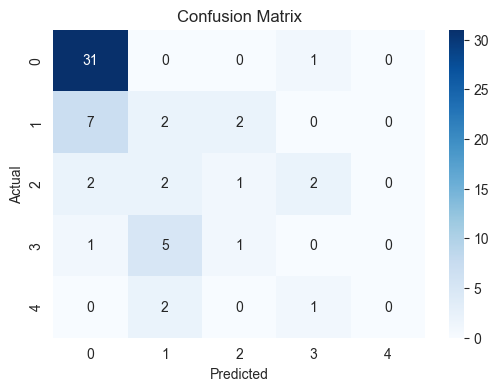

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.


## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.


In [22]:
# Get feature importances from Random Forest
importances = rf.feature_importances_

# Create dataframe
fi = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

# Show top features
fi.head(15)

,feature,importance
15,heart_stress,0.086686
7,thalach,0.077312
9,oldpeak,0.075299
17,heart_stress_index,0.071900
11,ca,0.067275
13,chol_age_ratio,0.066742
4,chol,0.065569
14,bp_chol_risk,0.062142
0,age,0.061157
16,chol_bp_ratio,0.059761


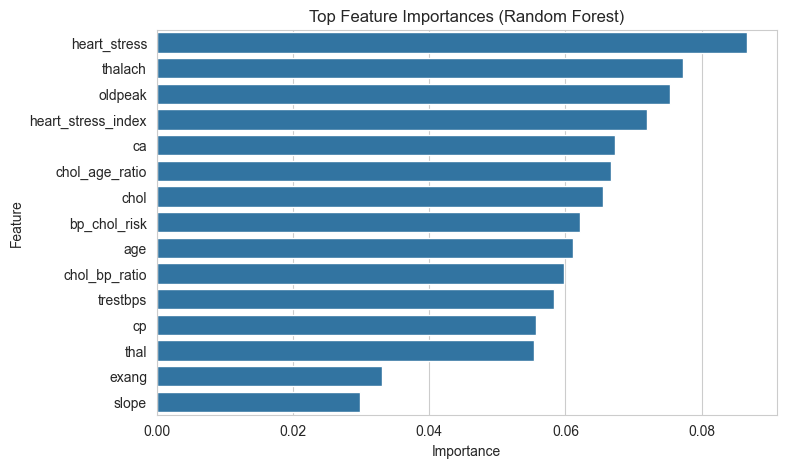

In [23]:
plt.figure(figsize=(8,5))

top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")

plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

This chart shows which medical features contributed the most to predicting heart disease.

Higher importance values indicate that the feature played a stronger role in the Random Forest model's decisions.

## 14. Optional: Feature selection using SelectFromModel

We can use the Random Forest model to automatically select the most important features.

This step keeps features whose importance is above the median importance score.

In [24]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Create feature selector using Random Forest
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    threshold="median"
)

# Fit selector
selector.fit(X_train, y_train)

# Transform data
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Train model again using selected features
rf_selected = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_selected.fit(X_train_selected, y_train)

# Predictions
y_pred_fs = rf_selected.predict(X_test_selected)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))

Accuracy (with feature selection): 0.6

Classification Report (with feature selection):
              precision    recall  f1-score   support

           0       0.73      0.94      0.82        32
           1       0.17      0.18      0.17        11
           2       0.67      0.29      0.40         7
           3       0.67      0.29      0.40         7
           4       0.00      0.00      0.00         3

    accuracy                           0.60        60
   macro avg       0.45      0.34      0.36        60
weighted avg       0.58      0.60      0.56        60



Feature selection keeps only the most informative variables.

If the model performance remains similar, this indicates that fewer features can achieve comparable predictive performance.

## 15. Student tasks

### Task 1
Create one new engineered feature that you believe will help predict `Order_Status`.  
Write one paragraph justifying your choice.

### Task 2
Try a different rule for `is_peak_hour` and discuss whether performance changes.

### Task 3
Change `top_k` in `Item_Name_reduced` (for example 10, 30, 50) and compare:
- accuracy
- top feature importances

### Task 4
Run the optional feature selection section and explain whether it was beneficial in your case.


## Wrap-up
In this lab, the dataset was already clean, so our focus was on feature engineering.  
We engineered time-based, price-based, and category-reduction features, then evaluated a baseline classifier and interpreted feature importance.
